<a href="https://www.kaggle.com/code/nilotpaldhar/fashion-mnist-classification-using-vgg16-gpup100?scriptVersionId=302900392" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Fashion-MNIST Classification using VGG16</div>
<p align="center">
Deep Learning • Transfer Learning • PyTorch • Computer Vision
</p>

 <a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Import Required Libraries</div>

<p>
Before building and training our <b style="color:#8E44AD;">Deep Learning model</b>, we need to import several 
<b style="color:#E67E22;">Python libraries</b>. These libraries help with <b style="color:#27AE60;">data processing</b>, 
<b style="color:#C0392B;">model building</b>, <b style="color:#AF7AC5;">training</b>, and <b style="color:#16A085;">visualization</b>.
</p>

<ul>

<li><span style="color:#E67E22;"><b>Pandas</b></span> – Used for loading and manipulating structured datasets.</li>

<li><span style="color:#3498DB;"><b>Scikit-learn</b></span> – Helps split the dataset into <b>training</b> and <b>testing</b> sets.</li>

<li><span style="color:#27AE60;"><b>PyTorch</b></span> – The main deep learning framework used to build and train neural networks.</li>

<li><span style="color:#8E44AD;"><b>Dataset & DataLoader</b></span> – Efficiently handle and load data during model training.</li>

<li><span style="color:#C0392B;"><b>torch.nn</b></span> – Provides neural network layers and architectures.</li>

<li><span style="color:#AF601A;"><b>torch.optim</b></span> – Contains optimization algorithms such as Adam and SGD.</li>

<li><span style="color:#16A085;"><b>Matplotlib</b></span> – Used to visualize training results and model performance.</li>

<li><span style="color:#D35400;"><b>NumPy</b></span> – Provides fast numerical operations and array processing.</li>

<li><span style="color:#7D3C98;"><b>torchvision</b></span> – Offers tools for image transformations and pretrained deep learning models.</li>

<li><span style="color:#2E86C1;"><b>PIL (Python Imaging Library)</b></span> – Used to load and process image data.</li>

</ul>

<p style="color:#B03A2E;"><b> These libraries together form the foundation for building and training our deep learning pipeline.</b></p>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from PIL import Image
import numpy as np
import torchvision.models as models

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Device Configuration</div>
<p>
Deep learning models can run on different types of hardware. In this step, we check whether a 
<b style="color:#27AE60;">GPU (CUDA)</b> is available for faster computation.  
If a GPU is available, the model will automatically use it; otherwise, it will run on the 
<b style="color:#E67E22;">CPU</b>.
</p>

<ul>
<li><span style="color:#8E44AD;"><b>CUDA</b></span> – Used for accelerating deep learning computations on GPU.</li>
<li><span style="color:#C0392B;"><b>CPU</b></span> – Used when GPU is not available.</li>
</ul>

<p style="color:#16A085;"><b> Using a GPU significantly speeds up model training and inference.</b></p>

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Loading the Dataset</div>
<p>
In this step, we load the <b style="color:#8E44AD;">Fashion-MNIST dataset</b>, which is a popular benchmark dataset used for 
<b style="color:#27AE60;">image classification tasks</b> in deep learning.
</p>

<ul>
<li><span style="color:#E67E22;"><b>Dataset:</b></span> Fashion-MNIST</li>
<li><span style="color:#C0392B;"><b>Content:</b></span> 28×28 grayscale images of clothing items</li>
<li><span style="color:#16A085;"><b>Classes:</b></span> 10 fashion categories (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)</li>
</ul>

<p>
We use <b style="color:#3498DB;">Pandas</b> to read the dataset from the Kaggle input directory and display the first few rows to understand its structure.
</p>

<p style="color:#AF601A;"><b> This helps us verify that the dataset is loaded correctly before preprocessing.</b></p>

In [4]:
df = pd.read_csv(r'/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(60000, 785)

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Visualizing Sample Images</div>
<p>
Before training the model, it is important to <b style="color:#27AE60;">explore the dataset visually</b>.  
In this step, we display the <b style="color:#8E44AD;">first 16 images</b> from the <b style="color:#E67E22;">Fashion-MNIST dataset</b>.
</p>

<ul>
<li><span style="color:#C0392B;"><b>Image Size:</b></span> 28 × 28 grayscale pixels</li>
<li><span style="color:#16A085;"><b>Total Classes:</b></span> 10 different clothing categories</li>
<li><span style="color:#AF601A;"><b>Goal:</b></span> Understand how the images look before feeding them into the model</li>
</ul>

<p>
Using <b style="color:#3498DB;">Matplotlib</b>, we create a <b>4 × 4 grid</b> to display the first 16 images along with their corresponding labels.
</p>

<p style="color:#7D3C98;"><b> This helps verify that the dataset is loaded correctly and gives an intuitive understanding of the image data.</b></p>

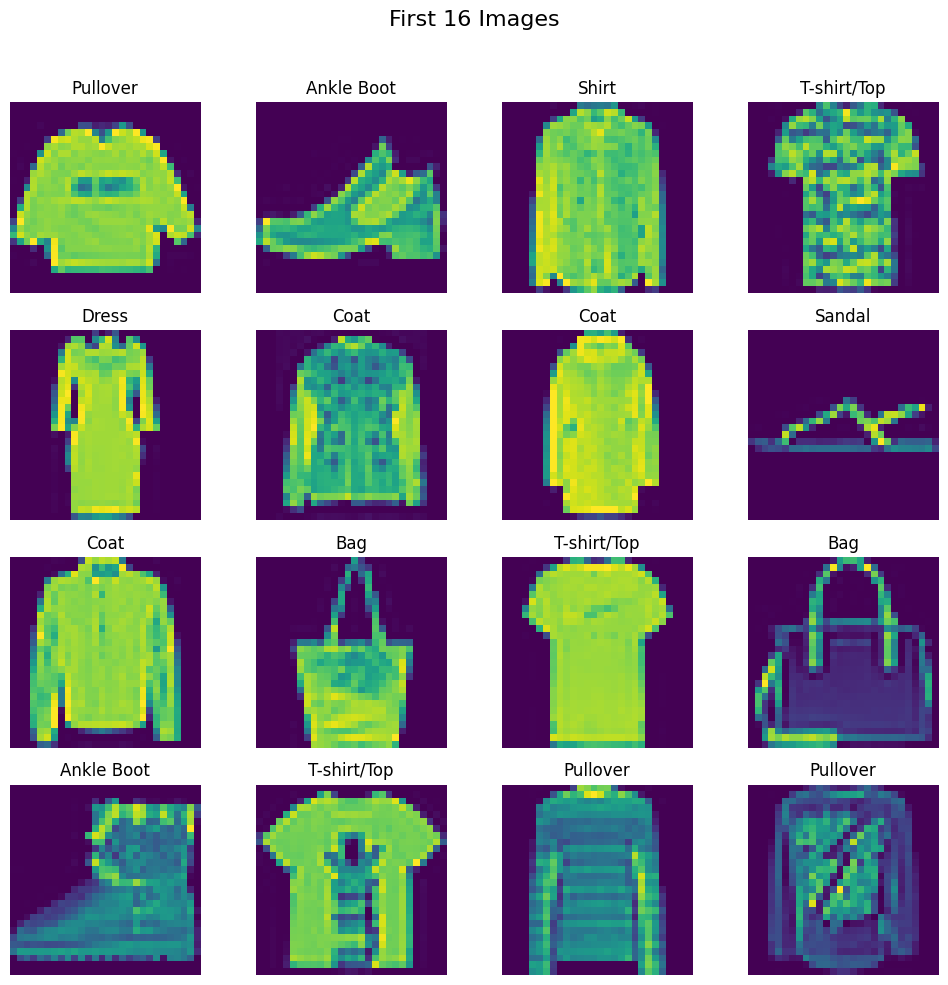

In [6]:
labels_map = {
0: "T-shirt/Top",
1: "Trouser",
2: "Pullover",
3: "Dress",
4: "Coat",
5: "Sandal",
6: "Shirt",
7: "Sneaker",
8: "Bag",
9: "Ankle Boot"
}

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(labels_map[df.iloc[i,0]])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Data Preprocessing & Custom Dataset</div>
<p>
Before training the deep learning model, we need to <b style="color:#27AE60;">prepare the dataset</b> so it can be properly used by PyTorch.
In this step, we apply <b style="color:#8E44AD;">image transformations</b> and create a <b style="color:#E67E22;">custom dataset class</b>.
</p>

<h3 style="color:#AF7AC5;"> Image Transformations</h3>

<ul>
<li><span style="color:#C0392B;"><b>Resize</b></span> – Adjusts the image size to match the input requirements of pretrained models.</li>
<li><span style="color:#16A085;"><b>Center Crop</b></span> – Crops the center portion of the image for consistent input dimensions.</li>
<li><span style="color:#2E86C1;"><b>ToTensor</b></span> – Converts images into PyTorch tensors.</li>
<li><span style="color:#D35400;"><b>Normalize</b></span> – Standardizes pixel values using ImageNet mean and standard deviation.</li>
</ul>

In [9]:
custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Custom PyTorch Dataset</div>
<p>
We create a <b style="color:#27AE60;">CustomDataset class</b> that extends the PyTorch <b>Dataset</b> class.  
This allows us to efficiently load images and labels during training.
</p>

<ul>
<li>Reshape raw pixel values into <b>28×28 images</b></li>
<li>Convert grayscale images into <b>3-channel RGB format</b></li>
<li>Convert NumPy arrays to <b>PIL images</b></li>
<li>Apply the defined <b>transformations</b></li>
</ul>

In [10]:
class CustomDataset(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    image = self.features[index].reshape(28,28)

    image = image.astype(np.uint8)

    image = np.stack([image]*3, axis=-1)

    image = Image.fromarray(image)

    image = self.transform(image)

    return image, torch.tensor(self.labels[index], dtype=torch.long)

In [11]:
train_dataset = CustomDataset(X_train, y_train, transform=custom_transform)
test_dataset = CustomDataset(X_test, y_test, transform=custom_transform)

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">DataLoader</div>

<p>
Finally, we create <b style="color:#E67E22;">DataLoader objects</b> for the training and testing datasets.
These loaders help in:
</p>

<ul>
<li>Efficient <b>batch processing</b></li>
<li><b>Shuffling</b> training data</li>
<li>Faster <b>GPU memory transfer</b> using <b>pin_memory</b></li>
</ul>

<p style="color:#7D3C98;"><b> This pipeline prepares the dataset so it can be efficiently used for training deep learning models.</b></p>

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Loading Pretrained VGG16 Model (Transfer Learning)</div>
<p>
In this step, we load the <b style="color:#8E44AD;">VGG16 deep learning model</b> that has been 
<b style="color:#27AE60;">pretrained on the ImageNet dataset</b>.  
Using a pretrained model helps us leverage <b style="color:#E67E22;">existing learned features</b> such as edges, textures, and shapes.
</p>

<h3 style="color:#AF7AC5;"> Why Use Transfer Learning?</h3>

<ul>
<li><span style="color:#C0392B;"><b>Faster Training</b></span> – The model already learned useful visual patterns.</li>
<li><span style="color:#16A085;"><b>Better Performance</b></span> – Works well even with smaller datasets.</li>
<li><span style="color:#2E86C1;"><b>Reduced Computation</b></span> – No need to train the entire network from scratch.</li>
</ul>

<h3 style="color:#AF7AC5;"> Freezing Feature Layers</h3>

<p>
We freeze the <b style="color:#D35400;">feature extraction layers</b> of the VGG16 model by setting 
<b>requires_grad = False</b>.  
This means the convolutional layers will <b>not be updated during training</b>, and only the 
<b style="color:#27AE60;">final classification layers</b> will learn from our dataset.
</p>

<p style="color:#7D3C98;"><b> This approach improves training efficiency and prevents overfitting.</b></p>

In [13]:
#vgg16 = models.vgg16(pretrained=True)
from torchvision import models
from torchvision.models import VGG16_Weights

vgg16 = models.vgg16(weights=VGG16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 225MB/s]


In [14]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
for param in vgg16.features.parameters():
  param.requires_grad=False

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Customizing the VGG16 Classifier</div>

<p>
The original <b style="color:#8E44AD;">VGG16 model</b> is designed to classify 
<b style="color:#27AE60;">1000 ImageNet classes</b>. However, our dataset 
(<b style="color:#E67E22;">Fashion-MNIST</b>) contains only <b>10 clothing categories</b>.
Therefore, we need to <b style="color:#C0392B;">modify the classifier layer</b> of VGG16.
</p>

<h3 style="color:#AF7AC5;"> What We Are Doing</h3>

<ul>
<li><span style="color:#2E86C1;"><b>Replace the original classifier</b></span> with a new neural network.</li>
<li>Add <b style="color:#16A085;">fully connected layers</b> to learn patterns specific to the Fashion-MNIST dataset.</li>
<li>Use <b style="color:#D35400;">ReLU activation</b> to introduce non-linearity.</li>
<li>Apply <b style="color:#7D3C98;">Dropout</b> to reduce overfitting.</li>
<li>Set the final layer to <b style="color:#27AE60;">10 output neurons</b> representing the 10 fashion classes.</li>
</ul>

<p>
This customized classifier allows the pretrained <b>VGG16 feature extractor</b> to work with our dataset.
</p>

<p style="color:#B03A2E;"><b> By modifying the classifier, we adapt the powerful VGG16 architecture to our specific classification task.</b></p>

In [16]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128,10),
)

In [17]:
vgg16 = vgg16.to(device)

In [18]:
learning_rate = 0.0001
epochs = 100

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate)

<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Model Training</div>

<p>
In this step, we train our <b style="color:#8E44AD;">VGG16-based deep learning model</b> using the 
<b style="color:#E67E22;">Fashion-MNIST dataset</b>. The model learns to classify clothing images into 
<b style="color:#27AE60;">10 different categories</b>.
</p>

<h3 style="color:#AF7AC5;"> Training Configuration</h3>

<ul>
<li><span style="color:#C0392B;"><b>Device</b></span> – The model is moved to <b>GPU (CUDA)</b> if available, otherwise it runs on the CPU.</li>
<li><span style="color:#2E86C1;"><b>Learning Rate</b></span> – Controls how fast the model updates its weights during training.</li>
<li><span style="color:#16A085;"><b>Epochs</b></span> – The number of times the model sees the entire training dataset.</li>
<li><span style="color:#D35400;"><b>Loss Function</b></span> – <b>CrossEntropyLoss</b> is used for multi-class classification.</li>
<li><span style="color:#7D3C98;"><b>Optimizer</b></span> – <b>Adam optimizer</b> updates the model parameters efficiently.</li>
</ul>

<h3 style="color:#AF7AC5;"> Training Process</h3>

<p>
During training, the following steps are performed for each batch:
</p>

<ul>
<li>Move input data and labels to the selected <b>device</b></li>
<li>Perform a <b style="color:#27AE60;">forward pass</b> through the model</li>
<li>Compute the <b style="color:#C0392B;">loss</b> between predictions and true labels</li>
<li>Perform <b style="color:#2E86C1;">backpropagation</b> to calculate gradients</li>
<li>Update model weights using the <b style="color:#E67E22;">optimizer</b></li>
</ul>

<p style="color:#B03A2E;"><b> This iterative process allows the model to gradually learn patterns in the dataset and improve its classification performance.</b></p>

In [20]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    print(outputs.shape)
    print(batch_labels.shape)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

    break

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

torch.Size([32, 10])
torch.Size([32])
Epoch: 1 , Loss: 0.0015325063069661457
torch.Size([32, 10])
torch.Size([32])
Epoch: 2 , Loss: 0.001506747563680013
torch.Size([32, 10])
torch.Size([32])
Epoch: 3 , Loss: 0.0014905729293823243
torch.Size([32, 10])
torch.Size([32])
Epoch: 4 , Loss: 0.00147080135345459
torch.Size([32, 10])
torch.Size([32])
Epoch: 5 , Loss: 0.0014474202791849773
torch.Size([32, 10])
torch.Size([32])
Epoch: 6 , Loss: 0.0014046552975972495
torch.Size([32, 10])
torch.Size([32])
Epoch: 7 , Loss: 0.0013578553199768066
torch.Size([32, 10])
torch.Size([32])
Epoch: 8 , Loss: 0.0013010546366373698
torch.Size([32, 10])
torch.Size([32])
Epoch: 9 , Loss: 0.001277551015218099
torch.Size([32, 10])
torch.Size([32])
Epoch: 10 , Loss: 0.0012046085993448893
torch.Size([32, 10])
torch.Size([32])
Epoch: 11 , Loss: 0.0011613380908966065
torch.Size([32, 10])
torch.Size([32])
Epoch: 12 , Loss: 0.001148319403330485
torch.Size([32, 10])
torch.Size([32])
Epoch: 13 , Loss: 0.0010320018132527668


<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Model Evaluation</div>
<p>
After training the model, we evaluate its performance on the 
<b style="color:#8E44AD;">test dataset</b>. This step helps us understand how well the model 
<b style="color:#27AE60;">generalizes to unseen data</b>.
</p>

<h3 style="color:#AF7AC5;"> Evaluation Process</h3>

<ul>
<li><span style="color:#C0392B;"><b>Disable Gradient Computation</b></span> – Using <b>torch.no_grad()</b> to speed up inference and reduce memory usage.</li>

<li><span style="color:#2E86C1;"><b>Forward Pass</b></span> – Pass the test images through the trained <b>VGG16 model</b>.</li>

<li><span style="color:#16A085;"><b>Prediction</b></span> – Select the class with the <b>highest probability</b> using <b>torch.max()</b>.</li>

<li><span style="color:#D35400;"><b>Accuracy Calculation</b></span> – Compare predicted labels with the true labels to count correct predictions.</li>
</ul>

<p>
Finally, we compute the <b style="color:#27AE60;">classification accuracy</b> by dividing the number of correct predictions by the total number of test samples.
</p>

<p style="color:#7D3C98;"><b> This metric helps us measure how effectively the model performs on new, unseen data.</b></p>

In [21]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8403333333333334


<a id="1"></a>
## <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Conclusion</div>

<p>
In this project, we built an <b style="color:#8E44AD;">image classification system</b> using a 
<b style="color:#27AE60;">pretrained VGG16 deep learning model</b>. The model was adapted using 
<b style="color:#E67E22;">transfer learning</b> to classify images from the 
<b style="color:#AF7AC5;">Fashion-MNIST dataset</b>.
</p>

<h3 style="color:#AF7AC5;"> Key Steps Completed</h3>

<ul>
<li><span style="color:#2E86C1;"><b>Data Loading</b></span> – Imported the Fashion-MNIST dataset.</li>

<li><span style="color:#16A085;"><b>Data Visualization</b></span> – Displayed sample images to understand the dataset.</li>

<li><span style="color:#C0392B;"><b>Data Preprocessing</b></span> – Converted grayscale images to RGB and applied transformations.</li>

<li><span style="color:#7D3C98;"><b>Transfer Learning</b></span> – Used the pretrained <b>VGG16</b> model.</li>

<li><span style="color:#D35400;"><b>Model Customization</b></span> – Modified the classifier layers for 10 clothing classes.</li>

<li><span style="color:#27AE60;"><b>Model Training</b></span> – Trained the network using the Adam optimizer and CrossEntropyLoss.</li>

<li><span style="color:#8E44AD;"><b>Model Evaluation</b></span> – Tested the model and calculated classification accuracy.</li>
</ul>

<h3 style="color:#AF7AC5;"> Future Improvements</h3>

<ul>
<li>Experiment with <b style="color:#2E86C1;">other architectures</b> like ResNet or EfficientNet.</li>

<li>Apply <b style="color:#16A085;">data augmentation</b> to improve generalization.</li>

<li>Fine-tune more layers of the pretrained network.</li>

<li>Train the model with <b style="color:#D35400;">more epochs</b> and hyperparameter tuning.</li>

<li>Use <b style="color:#7D3C98;">advanced techniques</b> like learning rate scheduling or early stopping.</li>
</ul>

<p style="color:#B03A2E;"><b> This project demonstrates how transfer learning can be used to efficiently build powerful image classification models using deep learning.</b></p>